# Implementando SARIMA

## Importando bibliotecas e o arquivo

In [87]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from pmdarima import model_selection
import pmdarima as pm

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
import plotly.express as px

In [88]:
data = pd.read_excel("./ITAIPU_MENSAL.xlsx", header=(1))
data.head()

,ANO,JAN,FEV,MAR,ABR,MAI,JUN,JUL,AGO,SET,OUT,NOV,DEZ
0,1931,16445,21715,23059,16537,12893,10841,8025,6059,7155,6709,6813,10737
1,1932,14357,16741,13818,11372,8441,8442,6648,5576,4857,7672,7152,13796
2,1933,16783,14300,10995,9232,7359,5637,4911,4193,3921,4685,4153,8045
3,1934,11072,9477,8966,7060,5358,4449,3633,2969,3417,3685,3117,8489
4,1935,12235,15428,14333,12001,8149,7727,5765,6837,6647,14279,8728,9094


## Transformação 

 Ajustando a base para uma coluna

In [89]:
#derretendo a base com pandas
data = data.melt(id_vars='ANO', var_name='MES', value_name='VAZAO')
data.head()

,ANO,MES,VAZAO
0,1931,JAN,16445
1,1932,JAN,14357
2,1933,JAN,16783
3,1934,JAN,11072
4,1935,JAN,12235


Fazendo o mapeamento dos meses e ajustando data

In [90]:
meses = {'JAN': '01', 'FEV':'02', 'MAR':'03', 'ABR':'04', 'MAI':'05', 'JUN':'06', 'JUL':'07', 'AGO':'08',
          'SET':'09', 'OUT':'10', 'NOV':'11', 'DEZ':'12'}
#mapeamento dos meses
data['MES'] = data['MES'].map(meses)
#unindo as oclunas de data
data['ANO-MES'] = data['ANO'].astype(str)+'-'+data['MES'].astype(str)
#convertendo para o tipo de data
data['ANO-MES'] = pd.to_datetime(data['ANO-MES'])
#ordenando os valores de forma ascendente
data = data[['ANO-MES','VAZAO']].sort_values(by=['ANO-MES'], ascending=True).reset_index(drop=True)
data



,ANO-MES,VAZAO
0,1931-01-01,16445
1,1931-02-01,21715
2,1931-03-01,23059
3,1931-04-01,16537
4,1931-05-01,12893
...,...,...
1027,2016-08-01,9954
1028,2016-09-01,8817
1029,2016-10-01,8550
1030,2016-11-01,9208


Separando os dados em treino e teste

In [91]:
base_treino = data.loc[(data['ANO-MES'].dt.year >=1931) & (data['ANO-MES'].dt.year <= 2010)].reset_index(drop=True)
base_teste = data.loc[(data['ANO-MES'].dt.year >=2011) & (data['ANO-MES'].dt.year <= 2016)].reset_index(drop=True)
base_treino

,ANO-MES,VAZAO
0,1931-01-01,16445
1,1931-02-01,21715
2,1931-03-01,23059
3,1931-04-01,16537
4,1931-05-01,12893
...,...,...
955,2010-08-01,6269
956,2010-09-01,5399
957,2010-10-01,9240
958,2010-11-01,8676


In [92]:
base_teste

,ANO-MES,VAZAO
0,2011-01-01,20641
1,2011-02-01,18088
2,2011-03-01,25646
3,2011-04-01,18636
4,2011-05-01,11806
...,...,...
67,2016-08-01,9954
68,2016-09-01,8817
69,2016-10-01,8550
70,2016-11-01,9208


## Análise exploratória

Plot padrão da base

<Axes: xlabel='ANO-MES', ylabel='VAZAO'>

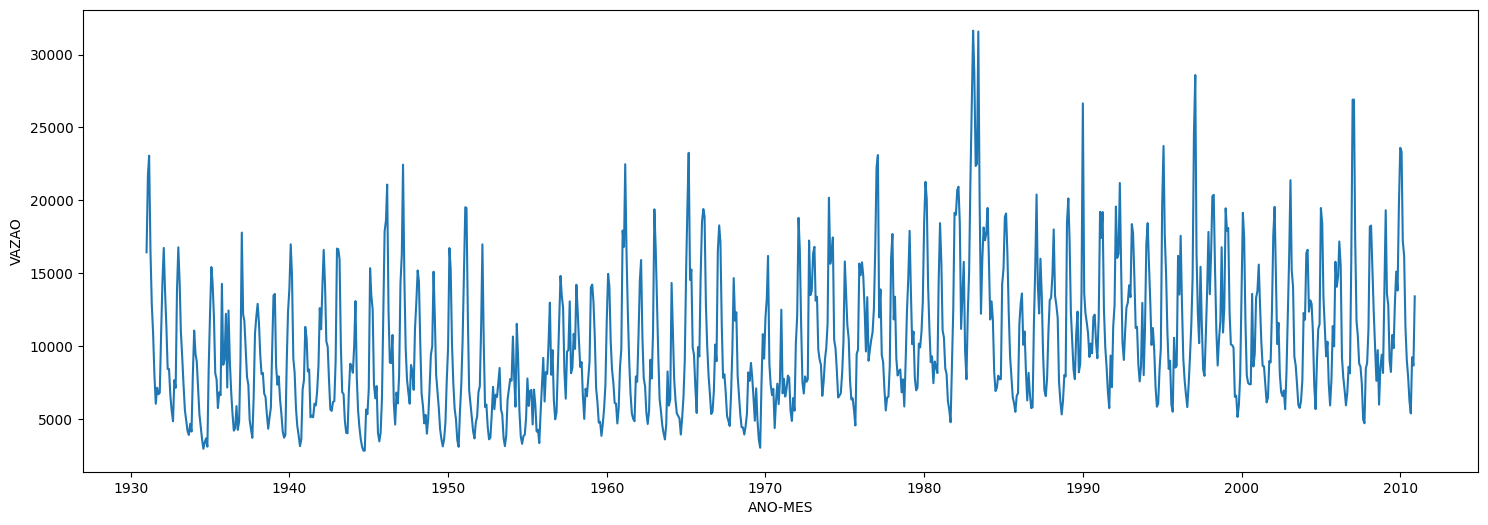

In [93]:
plt.figure(figsize=(18,6))
sns.lineplot(data=base_treino, x='ANO-MES', y='VAZAO')

Box-plot

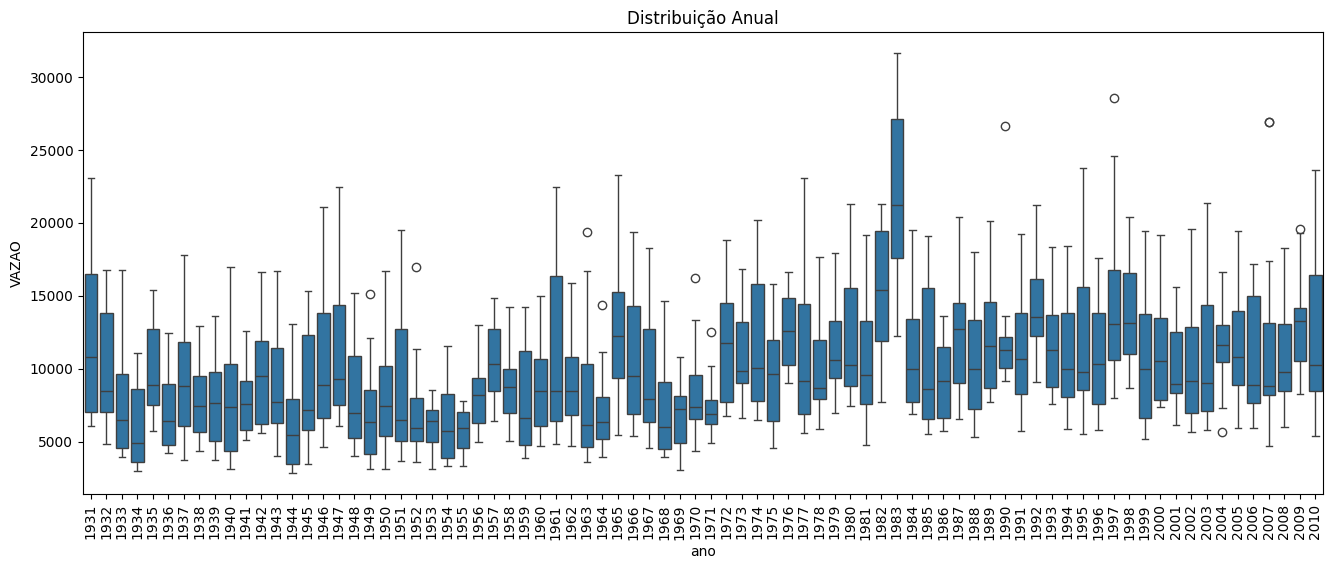

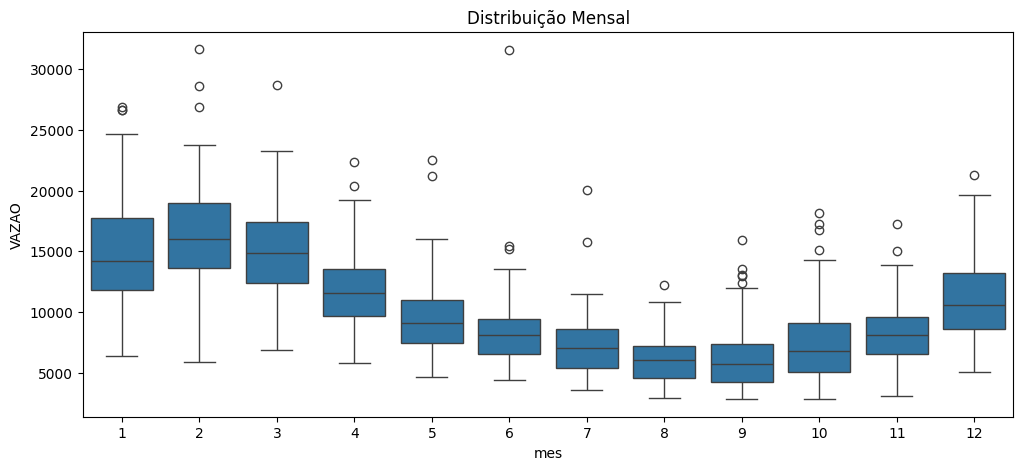

In [94]:
df_box_plot = base_treino.copy()
df_box_plot['ano'] = df_box_plot['ANO-MES'].dt.year
df_box_plot['mes'] = df_box_plot['ANO-MES'].dt.month

# Boxplot por ano
plt.figure(figsize=(16, 6))
sns.boxplot(x ='ano', y='VAZAO', data=df_box_plot) # Use 'Valor' as column name
plt.title('Distribuição Anual')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.show()

# Boxplot por mês
plt.figure(figsize=(12, 5))
sns.boxplot(x='mes', y='VAZAO', data=df_box_plot) # Use 'Valor' as column name
plt.title('Distribuição Mensal')
plt.show()

Plot da Tendência, sazonalidade e Resíduos

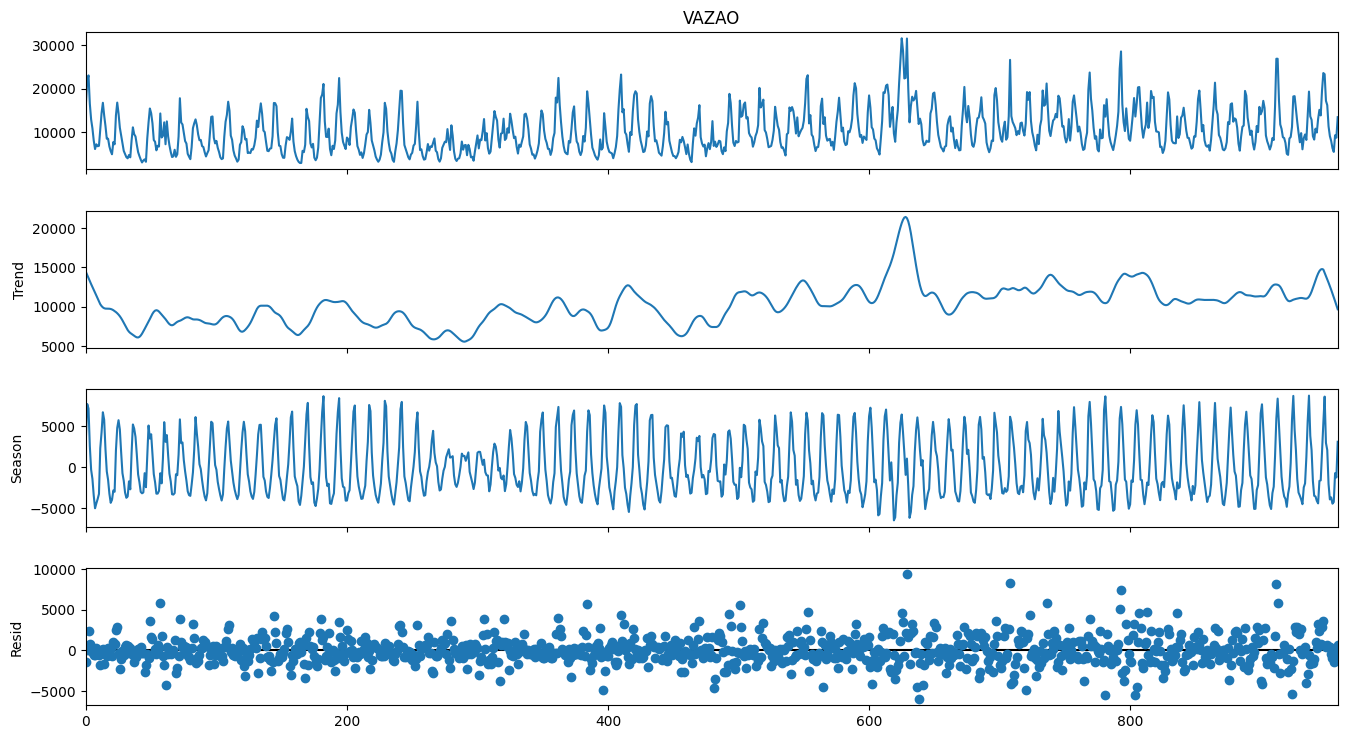

In [95]:
#definindo a vazao como indice para que dique melhor visualizavel graficamente
# data.set_index('ANO-MES', inplace=True)
# data_decomposto = seasonal_decompose(data['VAZAO'], model = 'additive', period=12)
stl = STL(base_treino['VAZAO'], period=12)
data_decomposto = stl.fit()
fig = data_decomposto.plot()
fig.set_size_inches(15,8)
plt.show()

## Teste de estacionariedade

Hipótese nula: série não estacionária  
Intervalo de confiança: 0,95  
Significância: 0,05  
  
P-value > 0.05 = série não estacionária  
P-value <= 0.05 = série estacionária 

In [96]:
#descobrindo o p-valor
teste_adf_result = adfuller(base_treino['VAZAO'].dropna())
print(f'O p-valor eh: {teste_adf_result[1]}')

O p-valor eh: 0.017940394930860658


## Visualizando Autocorrelação

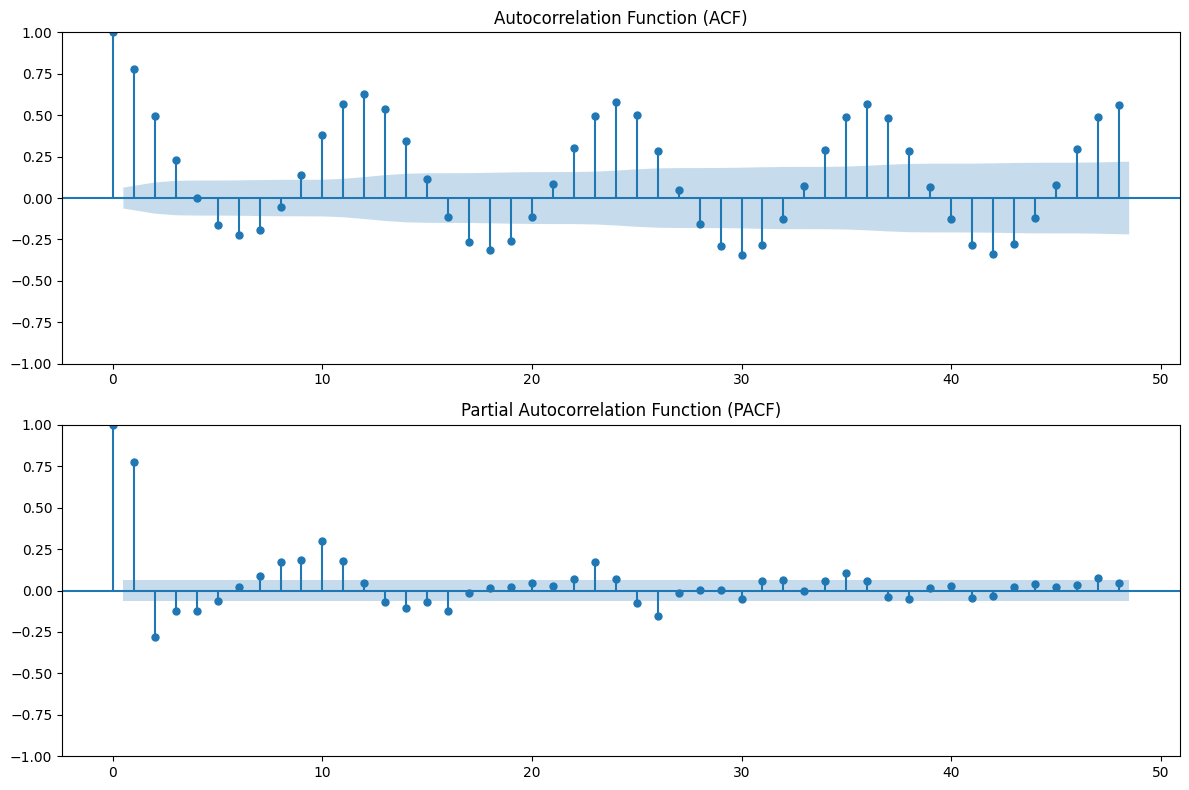

In [97]:
# definindo o numero de lags para visualizacao
n_lags = 48 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Gráfico ACF (para ordens q e Q)
plot_acf(base_treino['VAZAO'], lags=n_lags, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')

# Gráfico PACF (para ordens p e P)
plot_pacf(base_treino['VAZAO'], lags=n_lags, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

## Treinando os modelos

### ARIMA

In [98]:
# Criar modelo ARIMA  
historico_arima = list(base_treino['VAZAO'])
previsoes_arima = []

for t in range(len(base_teste)):
    arima = SARIMAX(historico_arima,
    order=(3,0,1),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing= False)
    fit = arima.fit()
    yhat = fit.forecast()[0]
    previsoes_arima.append(yhat)
    historico_arima.append(base_teste['VAZAO'].iloc[t])

print(fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1031
Model:               SARIMAX(3, 0, 1)   Log Likelihood               -9749.593
Date:                Wed, 12 Nov 2025   AIC                          19509.186
Time:                        20:36:09   BIC                          19533.863
Sample:                             0   HQIC                         19518.552
                               - 1031                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5169      0.197      2.630      0.009       0.132       0.902
ar.L2          0.4721      0.213      2.212      0.027       0.054       0.890
ar.L3         -0.0619      0.041     -1.520      0.1

### SARIMA

In [99]:
historico_sarima = list(base_treino['VAZAO'])
previsoes_sarima = []

for t in range(len(base_teste)):
    sarima = SARIMAX(historico_sarima,
    # order=(3,0,3),
    order=(3,0,1),
    # seasonal_order=(2, 0, 0, 12),
    seasonal_order=(3, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing= False)
    fit = sarima.fit()
    yhat = fit.forecast()[0]
    previsoes_sarima.append(yhat)
    historico_sarima.append(base_teste['VAZAO'].iloc[t])

print(fit.summary())

c:\Users\Notebook\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Notebook\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Notebook\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Notebook\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Like

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                 1031
Model:             SARIMAX(3, 0, 1)x(3, 0, 1, 12)   Log Likelihood               -9212.124
Date:                            Wed, 12 Nov 2025   AIC                          18442.248
Time:                                    20:53:25   BIC                          18486.345
Sample:                                         0   HQIC                         18459.014
                                           - 1031                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3067      0.236      5.548      0.000       0.845       1.768
ar.L2         -0.4204      0.156   

## Avaliando as previsões

### ARIMA

In [106]:
mae_arima = mean_absolute_error(base_teste['VAZAO'], previsoes_arima)
rmse_arima = root_mean_squared_error(base_teste['VAZAO'], previsoes_arima)
mape_arima = mean_absolute_percentage_error(base_teste['VAZAO'], previsoes_arima)

print(f"MAE  = {mae_arima:.3f}")
print(f"RMSE = {rmse_arima:.3f}")
print(f"RMSE = {mape_arima*100:.3f}%")

MAE  = 3175.958
RMSE = 4023.529
RMSE = 25.564%


### SARIMA

In [107]:
mae_sarima = mean_absolute_error(base_teste['VAZAO'], previsoes_sarima)
rmse_sarima = root_mean_squared_error(base_teste['VAZAO'], previsoes_sarima)
mape_sarima = mean_absolute_percentage_error(base_teste['VAZAO'], previsoes_sarima)

print(f"MAE  = {mae_sarima:.3f}")
print(f"RMSE = {rmse_sarima:.3f}")
print(f"MAPE = {mape_sarima*100:.3f}%")

MAE  = 2595.006
RMSE = 3394.632
MAPE = 21.793%


## Plotando o gráfico do real x previsto

In [102]:
# previsoes_arima.append(8500)
# previsoes_arima[1:]

#

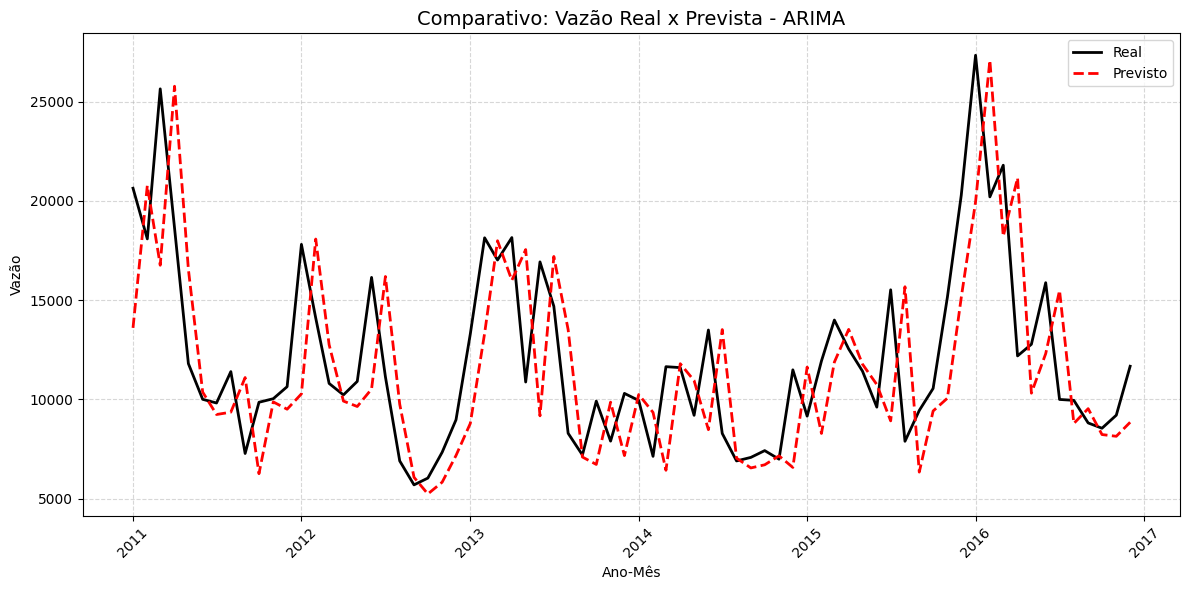

In [108]:
plt.figure(figsize=(12,6))

plt.plot(base_teste['ANO-MES'], base_teste['VAZAO'], label='Real', color='black', linewidth=2)
plt.plot(base_teste['ANO-MES'], previsoes_arima, label='Previsto', color='red', linestyle='--', linewidth=2)

plt.title('Comparativo: Vazão Real x Prevista - ARIMA', fontsize=14)
plt.xlabel('Ano-Mês')
plt.ylabel('Vazão')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


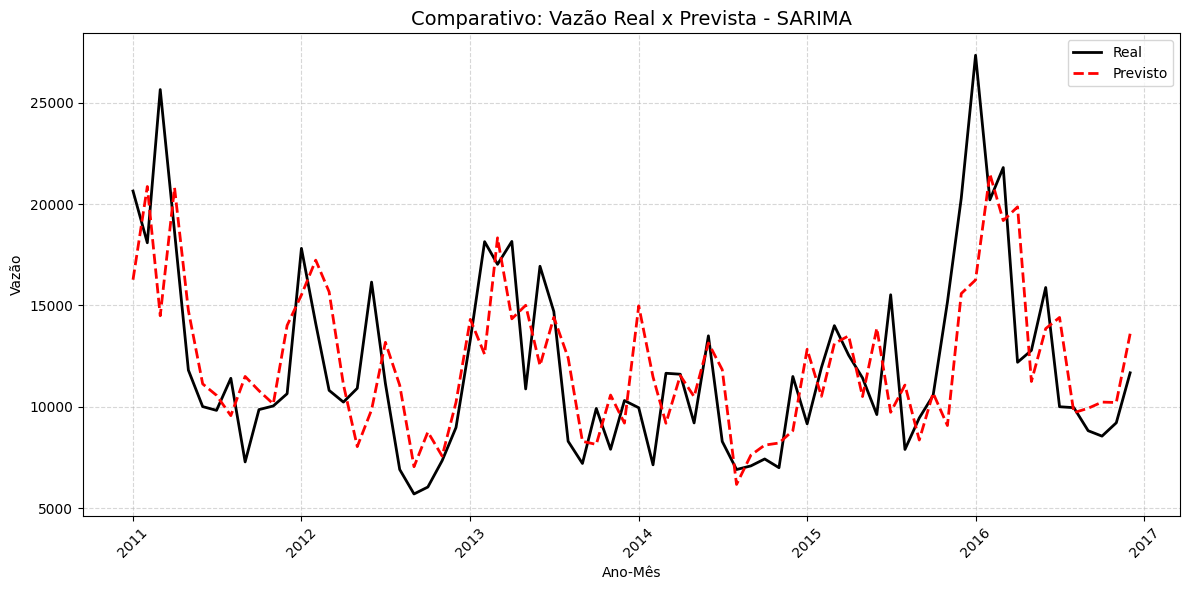

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(base_teste['ANO-MES'], base_teste['VAZAO'], label='Real', color='black', linewidth=2)
plt.plot(base_teste['ANO-MES'], previsoes_sarima, label='Previsto', color='red', linestyle='--', linewidth=2)

plt.title('Comparativo: Vazão Real x Prevista - SARIMA', fontsize=14)
plt.xlabel('Ano-Mês')
plt.ylabel('Vazão')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
